# Cardiovascular Disease Prediction
## Notebook 02: Random Forest Classifier
---
**Author:** MS26912448 (Member 1)
**Algorithm:** Random Forest (Ensemble – Bagging of Decision Trees)

### Algorithm Background

A **Random Forest** is an ensemble learning method that constructs multiple decision trees
during training and outputs the **mode** (majority vote) of their predictions.

#### Key Concepts:
- **Bootstrap Aggregation (Bagging):** Each tree is trained on a random sample (with replacement)
  of the training data, reducing variance.
- **Feature Randomness:** At each split, only a random subset of `√n` features is considered,
  decorrelating trees and reducing correlation between them.
- **Ensemble Prediction:** Final class = majority vote across all trees, reducing overfitting.

#### Why Random Forest for this Dataset?
1. Handles **mixed feature types** (binary, categorical, continuous) natively
2. **Robust to outliers** — uses splits, not distances
3. Provides **feature importance** — useful for clinical interpretation
4. Generally **does not require feature scaling**
5. Strong baseline performance on tabular medical data

In [15]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
os.makedirs('plots', exist_ok=True)

print("✓ Libraries imported.")

✓ Libraries imported.


In [16]:
import os

# ============================================================
# ENVIRONMENT SETUP — comment out the block you are NOT using
# ============================================================

# ── Google Colab Method ──────────────────────────────────
# Mounts Drive and changes to your project folder so
# preprocessed_data.pkl (saved by NB01) can be found here.
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_PATH = '/content/drive/MyDrive/ML-Assignment/attemp2'
# os.chdir(DRIVE_PATH)
# print(f"✓ Working directory: {DRIVE_PATH}")

# ── Local Jupyter Method ──────────────────────────────────
# Comment out this method above and uncomment the line below.
# All pkl files must be in the same folder as this notebook.
LOCAL_PATH = os.path.dirname(os.path.abspath("__file__"))
os.chdir(LOCAL_PATH)


In [17]:
# Load preprocessed data saved by Notebook 01
with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train      = data['X_train']
X_test       = data['X_test']
y_train      = data['y_train']
y_test       = data['y_test']
feature_names = data['feature_names']

print(f"✓ Data loaded successfully.")
print(f"  Training samples : {X_train.shape[0]:,}  |  Features: {X_train.shape[1]}")
print(f"  Test samples     : {X_test.shape[0]:,}")
print(f"  Feature names    : {feature_names}")

✓ Data loaded successfully.
  Training samples : 54,740  |  Features: 13
  Test samples     : 13,685
  Feature names    : ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi', 'bmi_category']


## 1. Baseline Random Forest Model

We first train a baseline model with default hyperparameters to establish a starting performance.

In [18]:
# Baseline Random Forest with default parameters
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

# Baseline metrics
acc  = accuracy_score(y_test, y_pred_base)
prec = precision_score(y_test, y_pred_base)
rec  = recall_score(y_test, y_pred_base)
f1   = f1_score(y_test, y_pred_base)
auc  = roc_auc_score(y_test, y_prob_base)

print("=== Baseline Random Forest Performance ===")
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {auc:.4f}")
print("\n", classification_report(y_test, y_pred_base, target_names=['No Disease','Has Disease']))

=== Baseline Random Forest Performance ===
  Accuracy  : 0.7046  (70.46%)
  Precision : 0.7044
  Recall    : 0.6940
  F1-Score  : 0.6991
  ROC-AUC   : 0.7619

               precision    recall  f1-score   support

  No Disease       0.70      0.72      0.71      6918
 Has Disease       0.70      0.69      0.70      6767

    accuracy                           0.70     13685
   macro avg       0.70      0.70      0.70     13685
weighted avg       0.70      0.70      0.70     13685



## 2. Hyperparameter Tuning with GridSearchCV

We tune key hyperparameters using **5-Fold Stratified Cross-Validation** optimising for **F1-score**
(better than accuracy for imbalanced classes).

| Parameter         | Values Tested         | Description                              |
|------------------|-----------------------|------------------------------------------|
| `n_estimators`   | 100, 200, 300         | Number of trees in the forest            |
| `max_depth`      | 10, 20, None          | Maximum depth of each tree               |
| `min_samples_split` | 2, 5              | Minimum samples to split a node          |
| `max_features`   | 'sqrt', 'log2'        | Features considered at each split        |

In [19]:
# Hyperparameter grid — kept compact for faster tuning
# (3-fold CV × 12 candidates = 36 fits, runs in ~1-2 min)
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("Starting GridSearchCV (3-fold, 12 candidates = 36 fits)...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\n✓ GridSearchCV complete.")
print(f"  Best parameters : {grid_search.best_params_}")
print(f"  Best CV F1      : {grid_search.best_score_:.4f}")


Starting GridSearchCV (3-fold, 12 candidates = 36 fits)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✓ GridSearchCV complete.
  Best parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
  Best CV F1      : 0.7159


In [20]:
# Retrieve and evaluate the best model
best_rf = grid_search.best_estimator_

print("=== Best RF Parameters ===")
for param, val in grid_search.best_params_.items():
    print(f"  {param}: {val}")

=== Best RF Parameters ===
  max_depth: 10
  max_features: sqrt
  min_samples_split: 5
  n_estimators: 100


## 3. Final Model Evaluation

### 3.1 Performance Metrics

In [21]:
# Evaluate best model on test set
y_pred_rf = best_rf.predict(X_test)
y_prob_rf  = best_rf.predict_proba(X_test)[:, 1]

# Compute all metrics
rf_metrics = {
    'accuracy':  accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall':    recall_score(y_test, y_pred_rf),
    'f1':        f1_score(y_test, y_pred_rf),
    'roc_auc':   roc_auc_score(y_test, y_prob_rf)
}

print("=== Random Forest – Final Test Results ===")
for metric, val in rf_metrics.items():
    bar = '█' * int(val * 30)
    print(f"  {metric:<12}: {val:.4f}  {bar}")

print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Disease', 'Has Disease']))

=== Random Forest – Final Test Results ===
  accuracy    : 0.7320  █████████████████████
  precision   : 0.7568  ██████████████████████
  recall      : 0.6749  ████████████████████
  f1          : 0.7135  █████████████████████
  roc_auc     : 0.7963  ███████████████████████

=== Detailed Classification Report ===
              precision    recall  f1-score   support

  No Disease       0.71      0.79      0.75      6918
 Has Disease       0.76      0.67      0.71      6767

    accuracy                           0.73     13685
   macro avg       0.73      0.73      0.73     13685
weighted avg       0.73      0.73      0.73     13685



### 3.2 Confusion Matrix

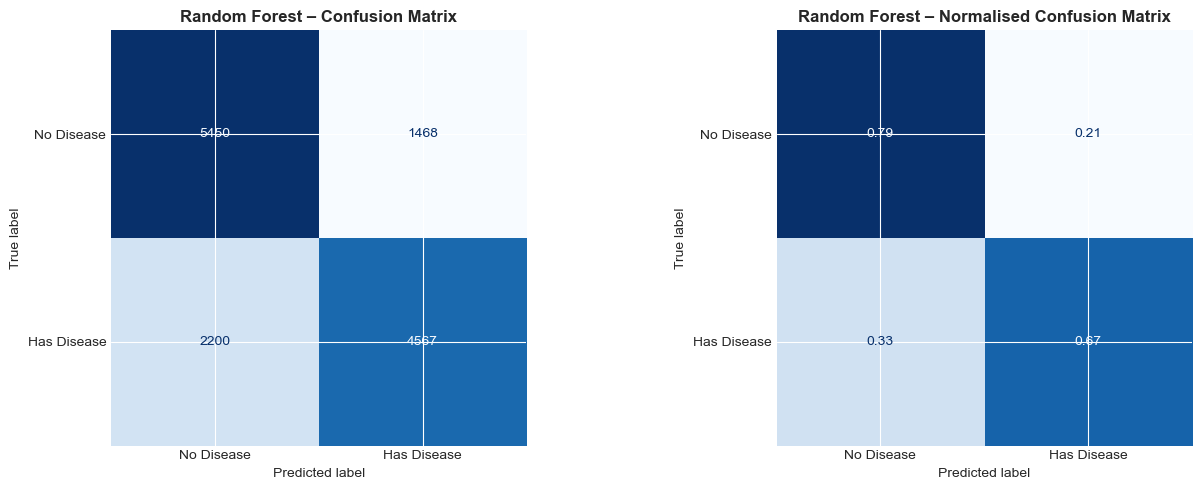

True Positives  (TP): 4,567
True Negatives  (TN): 5,450
False Positives (FP): 1,468
False Negatives (FN): 2,200


In [22]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Has Disease'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest – Confusion Matrix', fontsize=12, fontweight='bold')

# Normalised confusion matrix
cm_norm = confusion_matrix(y_test, y_pred_rf, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['No Disease', 'Has Disease'])
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title('Random Forest – Normalised Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/08_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (TP): {tp:,}")
print(f"True Negatives  (TN): {tn:,}")
print(f"False Positives (FP): {fp:,}")
print(f"False Negatives (FN): {fn:,}")

### 3.3 ROC Curve

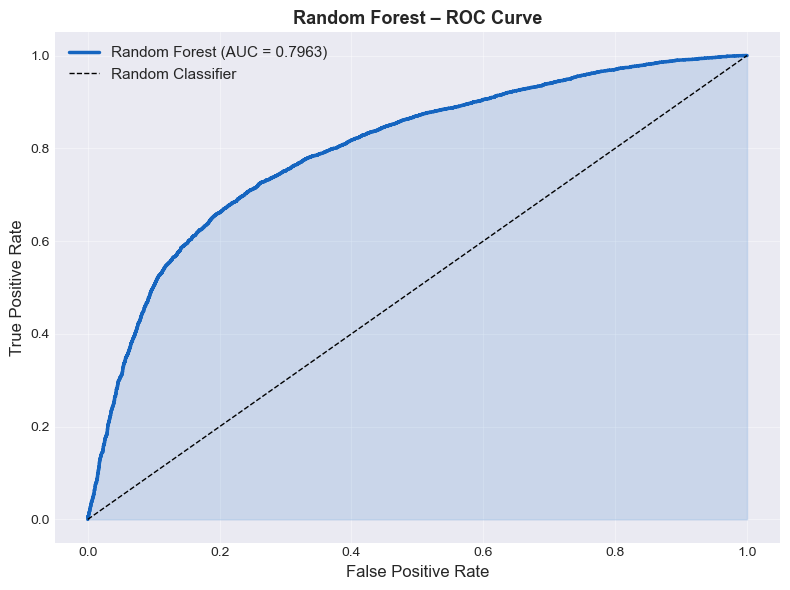

ROC-AUC Score: 0.7963


In [23]:
# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='#1565C0', linewidth=2.5,
         label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.fill_between(fpr_rf, tpr_rf, alpha=0.15, color='#1565C0')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Random Forest – ROC Curve', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('plots/09_rf_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC-AUC Score: {auc_rf:.4f}")

## 4. Feature Importance Analysis

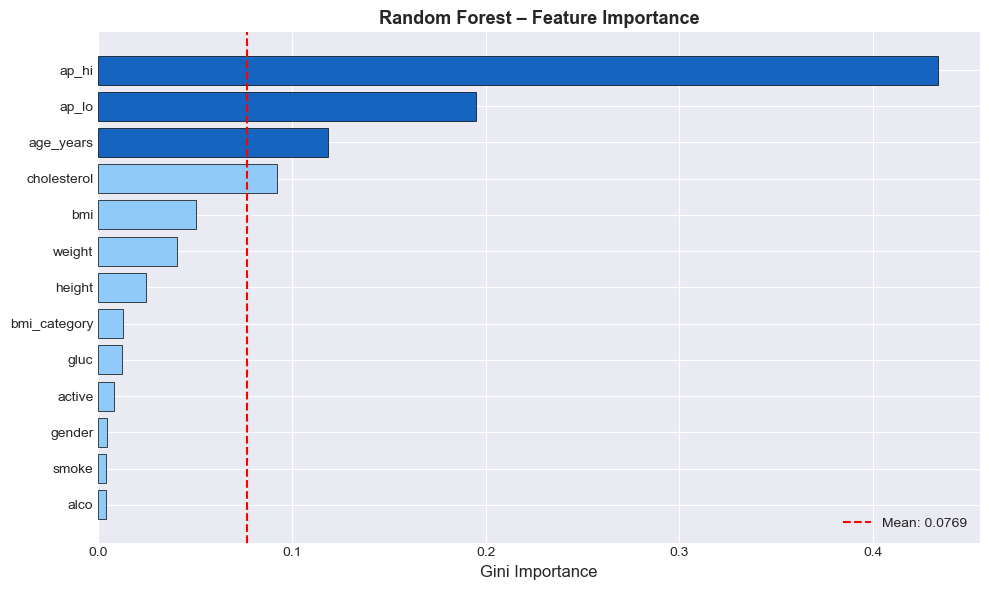

=== Feature Importance Ranking ===
  ap_hi          : 0.4337  ███████████████████████████████████████████
  ap_lo          : 0.1951  ███████████████████
  age_years      : 0.1187  ███████████
  cholesterol    : 0.0923  █████████
  bmi            : 0.0506  █████
  weight         : 0.0404  ████
  height         : 0.0246  ██
  bmi_category   : 0.0128  █
  gluc           : 0.0120  █
  active         : 0.0079  
  gender         : 0.0042  
  smoke          : 0.0041  
  alco           : 0.0038  


In [24]:
# Feature importance from the trained Random Forest
importances = best_rf.feature_importances_
imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#1565C0' if i >= len(imp_df)-3 else '#90CAF9'
          for i in range(len(imp_df))]
bars = plt.barh(imp_df['Feature'], imp_df['Importance'], color=colors,
                edgecolor='black', linewidth=0.5)
plt.xlabel('Gini Importance', fontsize=12)
plt.title('Random Forest – Feature Importance', fontsize=13, fontweight='bold')
plt.axvline(imp_df['Importance'].mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean: {imp_df["Importance"].mean():.4f}')
plt.legend()
plt.tight_layout()
plt.savefig('plots/10_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Feature Importance Ranking ===")
for _, row in imp_df.sort_values('Importance', ascending=False).iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"  {row['Feature']:<15}: {row['Importance']:.4f}  {bar}")

## 5. Cross-Validation (5-Fold)

In [25]:
# 5-Fold cross-validation on full training set for robust performance estimate
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)

print("=== 5-Fold Cross-Validation Results (F1-Score) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"\nThe low std ({cv_scores.std():.4f}) indicates the model generalises well.")

=== 5-Fold Cross-Validation Results (F1-Score) ===
  Fold 1: 0.7150
  Fold 2: 0.7158
  Fold 3: 0.7111
  Fold 4: 0.7178
  Fold 5: 0.7168
  Mean  : 0.7153 ± 0.0023

The low std (0.0023) indicates the model generalises well.


In [26]:
# Save model and results for comparison notebook
rf_results = {
    'model':         best_rf,
    'best_params':   grid_search.best_params_,
    'y_pred':        y_pred_rf,
    'y_prob':        y_prob_rf,
    'fpr':           fpr_rf,
    'tpr':           tpr_rf,
    'metrics':       rf_metrics,
    'cv_scores':     cv_scores,
    'feature_names': feature_names,
    'importances':   importances
}

with open('rf_results.pkl', 'wb') as f:
    pickle.dump(rf_results, f, protocol=4)

print("✓ RF results saved to 'rf_results.pkl'")
print("\n=== Random Forest Final Summary ===")
print(f"  Best Parameters : {grid_search.best_params_}")
for m, v in rf_metrics.items():
    print(f"  {m:<12}: {v:.4f}")

✓ RF results saved to 'rf_results.pkl'

=== Random Forest Final Summary ===
  Best Parameters : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
  accuracy    : 0.7320
  precision   : 0.7568
  recall      : 0.6749
  f1          : 0.7135
  roc_auc     : 0.7963
